# Tumour Volume Comparison: Simulation vs Romano et al. (2021)

Compares simulated tumour volume trajectories (with clonal heterogeneity) against
the experimental data from Romano et al. and Tanaya's baseline model.

**Approach:** Load all trials per scenario, average across trials, convert cell counts
to tumour volume (% of brain), and align the x-axis so that radiation at timestep 200
maps to Day 12 post-implantation (matching Romano et al.).

In [9]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "HALModeling2024Outs"

# Volume conversion constants (Tanaya's report, page 30)
VOXEL_VOLUME_MM3 = 0.001       # 100um x 100um x 100um
RAT_BRAIN_VOLUME_MM3 = 2000    # Fischer rat brain
GRID_CELLS = 10000             # 100x100 grid

# Radiation is applied at timestep 200, mapped to Day 12 (Romano et al.)
RADIATION_TIMESTEP = 200
RADIATION_DAY = 12

def timestep_to_day(timestep):
    """Convert simulation timestep to biological day post-implantation."""
    return RADIATION_DAY + (timestep - RADIATION_TIMESTEP)

def cell_count_to_volume_pct(count):
    """Convert cell count to tumour volume as % of rat brain."""
    return (count * VOXEL_VOLUME_MM3 / RAT_BRAIN_VOLUME_MM3) * 100

print("Setup complete.")

Setup complete.


### Load all trials per scenario and compute mean + std

In [10]:
def load_all_trials(scenario, min_date="20260415"):
    """
    Load all CSV trials for a scenario, filtering out old runs.
    Only includes files with timestamp >= min_date to avoid mixing
    pre-bug-fix / pre-heterogeneity data.
    """
    folder = os.path.join(BASE_DIR, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    
    if not csv_files:
        print(f"  WARNING: No CSVs found for {scenario}")
        return []
    
    # Filter by date: filename format is TrialRunCounts_YYYYMMDD_HHMMSS.csv
    filtered = []
    skipped = 0
    for f in csv_files:
        basename = os.path.basename(f)
        # Extract date portion: TrialRunCounts_YYYYMMDD_...
        date_part = basename.split('_')[1]
        if date_part >= min_date:
            filtered.append(f)
        else:
            skipped += 1
    
    if skipped > 0:
        print(f"  {scenario}: skipped {skipped} old runs (before {min_date})")
    
    if not filtered:
        print(f"  WARNING: No CSVs for {scenario} after date filter")
        return []
    
    trials = [pd.read_csv(f) for f in filtered]
    print(f"  {scenario}: {len(trials)} trials, {len(trials[0])} timesteps each")
    return trials

def compute_mean_volume(trials):
    """
    Given a list of trial DataFrames, compute mean and std of tumour volume
    at each timestep. Returns (days, mean_vol, std_vol).
    """
    min_len = min(len(df) for df in trials)
    
    # Stack TumorCells across trials
    all_counts = np.array([df['TumorCells'].values[:min_len] for df in trials])
    
    # Convert to volume %
    all_volumes = cell_count_to_volume_pct(all_counts)
    
    mean_vol = np.mean(all_volumes, axis=0)
    std_vol = np.std(all_volumes, axis=0)
    
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)
    
    return days, mean_vol, std_vol

# Scenarios matching Romano et al. treatment groups
scenarios = ["Control", "BB5", "BB10", "BB15", "MRT200", "MRT400", "MRT600", "MB180", "MB350"]

print("Loading trials (filtering out pre-April 15 runs)...")
scenario_data = {}
for scen in scenarios:
    trials = load_all_trials(scen)
    if trials:
        days, mean_vol, std_vol = compute_mean_volume(trials)
        scenario_data[scen] = {
            'days': days,
            'mean': mean_vol,
            'std': std_vol,
            'n_trials': len(trials)
        }

print(f"\nLoaded {len(scenario_data)} scenarios.")

Loading trials (filtering out pre-April 15 runs)...
  Control: 10 trials, 541 timesteps each
  BB5: 10 trials, 541 timesteps each
  BB10: 10 trials, 541 timesteps each
  BB15: 10 trials, 541 timesteps each
  MRT200: 10 trials, 541 timesteps each
  MRT400: 10 trials, 541 timesteps each
  MRT600: 10 trials, 541 timesteps each
  MB180: 10 trials, 541 timesteps each
  MB350: 10 trials, 541 timesteps each

Loaded 9 scenarios.


### Main comparison plot

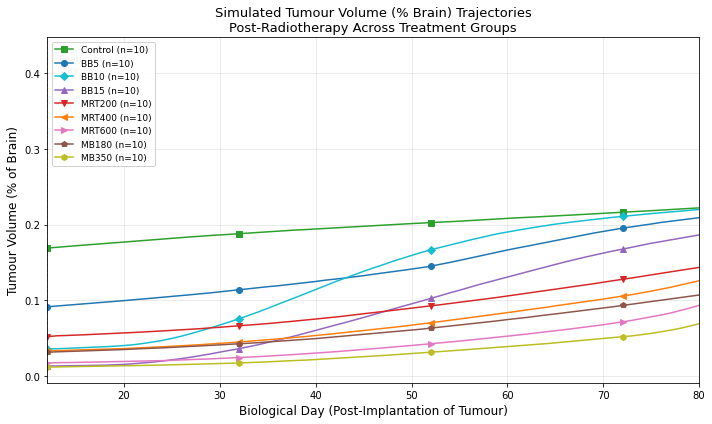

Saved to HALModeling2024Outs/tumour_volume_comparison.png


In [11]:
# Colour and style assignments to match Romano et al. figure conventions
scenario_style = {
    'Control':  {'color': '#2ca02c', 'marker': 's', 'label': 'Control'},
    'BB5':      {'color': '#1f77b4', 'marker': 'o', 'label': 'BB5'},
    'BB10':     {'color': '#17becf', 'marker': 'D', 'label': 'BB10'},
    'BB15':     {'color': '#9467bd', 'marker': '^', 'label': 'BB15'},
    'MRT200':   {'color': '#d62728', 'marker': 'v', 'label': 'MRT200'},
    'MRT400':   {'color': '#ff7f0e', 'marker': '<', 'label': 'MRT400'},
    'MRT600':   {'color': '#e377c2', 'marker': '>', 'label': 'MRT600'},
    'MB180':    {'color': '#8c564b', 'marker': 'p', 'label': 'MB180'},
    'MB350':    {'color': '#bcbd22', 'marker': 'h', 'label': 'MB350'},
}

fig, ax = plt.subplots(figsize=(10, 6))

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    style = scenario_style[scen]
    
    # Only plot from Day 12 onward (post-treatment) to match Romano/Tanaya
    mask = d['days'] >= RADIATION_DAY
    days = d['days'][mask]
    mean = d['mean'][mask]
    
    # Subsample markers so the plot isn't cluttered (every 20 timesteps)
    marker_every = 20
    
    ax.plot(days, mean,
            color=style['color'],
            marker=style['marker'],
            markevery=marker_every,
            markersize=6,
            linewidth=1.5,
            label=f"{style['label']} (n={d['n_trials']})")

# Mark treatment day
ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.text(RADIATION_DAY + 1, ax.get_ylim()[1] * 0.95, 'Treatment\n(Day 12)',
        fontsize=9, color='grey', va='top')

ax.set_xlabel('Biological Day (Post-Implantation of Tumour)', fontsize=12)
ax.set_ylabel('Tumour Volume (% of Brain)', fontsize=12)
ax.set_title('Simulated Tumour Volume (% Brain) Trajectories\n'
             'Post-Radiotherapy Across Treatment Groups', fontsize=13)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(RADIATION_DAY, 80)

plt.tight_layout()
plt.savefig('HALModeling2024Outs/tumour_volume_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/tumour_volume_comparison.png")

### Per-scenario subplots — ABM vs In Vivo

Each panel shows one radiation scenario. Blue lines with error bars = ABM simulation
mean ± SD across 10 runs. Dashed grey lines with × markers = Romano et al. (2021)
in vivo experimental data (where available). Both normalised to [0, 1] for shape comparison.

Top row: MRT (Pred_MRT180, MRT200, Pred_MRT350, MRT400, MRT600)
Bottom row: MB (MB180, Pred_MB200, MB350, Pred_MB400, Pred_MB600)

  Pred_MRT180: 10 trials loaded
  MRT200: 10 trials loaded
  Pred_MRT350: 10 trials loaded
  MRT400: 10 trials loaded
  MRT600: 10 trials loaded
  MB180: 10 trials loaded
  Pred_MB200: 10 trials loaded
  MB350: 10 trials loaded
  Pred_MB400: 10 trials loaded
  Pred_MB600: 10 trials loaded


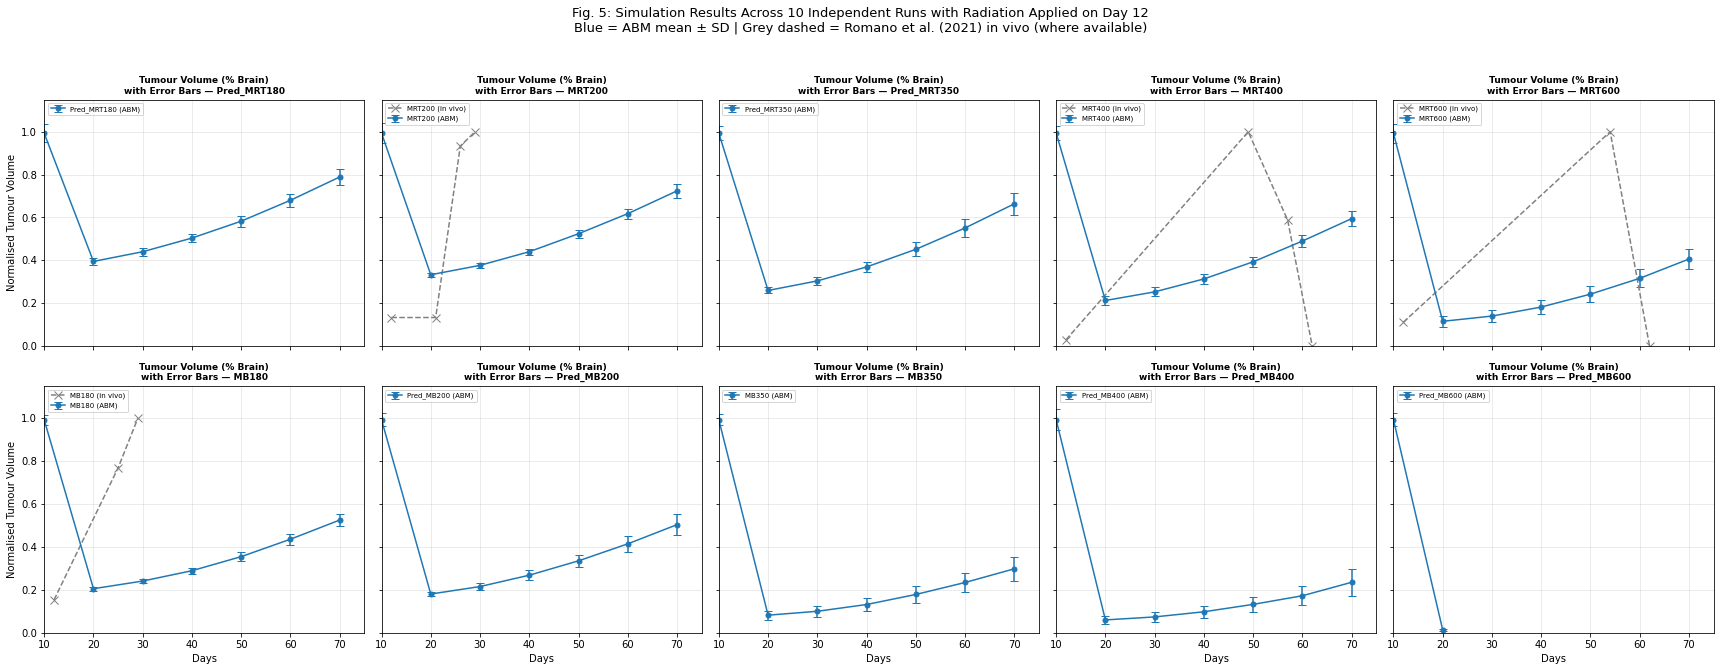

Saved to HALModeling2024Outs/per_scenario_runs_vs_invivo.png


In [12]:
# --- Romano et al. (2021) in vivo data (extracted from figures by Tanaya) ---
# Format: (day_post_implantation, tumour_volume_percent_of_brain)
in_vivo_data = {
    "MRT200":  [(12, 2), (21, 2), (26, 14), (29, 15)],
    "MRT400":  [(12, 2), (49, 68), (57, 40), (62, 0)],
    "MRT600":  [(12, 2), (54, 18), (62, 0)],
    "MB180":   [(12, 2), (25, 10), (29, 13)],
}

# --- Load individual trial volumes for ABM ---
def load_individual_volumes(scenario, min_date="20260415"):
    """Load each trial's tumour volume time series individually."""
    folder = os.path.join(BASE_DIR, f"Scenario{scenario}")
    csv_files = sorted(glob.glob(os.path.join(folder, "TrialRunCounts_*.csv")))
    filtered = [f for f in csv_files if os.path.basename(f).split('_')[1] >= min_date]
    if not filtered:
        return None, None
    trials = [pd.read_csv(f) for f in filtered]
    min_len = min(len(df) for df in trials)
    timesteps = trials[0]['Timestep'].values[:min_len]
    days = timestep_to_day(timesteps)
    all_volumes = np.array([
        cell_count_to_volume_pct(df['TumorCells'].values[:min_len])
        for df in trials
    ])
    return days, all_volumes

# Scenarios to plot: top row = MRT, bottom row = MB
# Map display label -> actual scenario folder name
scenario_map = {
    "Pred_MRT180": "Pred_MRT180",
    "MRT200":      "MRT200",
    "Pred_MRT350": "Pred_MRT350",
    "MRT400":      "MRT400",
    "MRT600":      "MRT600",
    "MB180":       "MB180",
    "Pred_MB200":  "Pred_MB200",
    "MB350":       "MB350",
    "Pred_MB400":  "Pred_MB400",
    "Pred_MB600":  "Pred_MB600",
}

plot_order = [
    ["Pred_MRT180", "MRT200", "Pred_MRT350", "MRT400", "MRT600"],
    ["MB180", "Pred_MB200", "MB350", "Pred_MB400", "Pred_MB600"],
]

# Pre-load ABM data
indiv_data = {}
for label, folder_name in scenario_map.items():
    days, vols = load_individual_volumes(folder_name)
    if days is not None:
        indiv_data[label] = {'days': days, 'volumes': vols}
        print(f"  {label}: {vols.shape[0]} trials loaded")
    else:
        print(f"  WARNING: No data for {label}")

# --- Plot: 2 rows x 5 cols ---
fig, axes = plt.subplots(2, 5, figsize=(24, 9), sharey=True, sharex=True)

DAY_MIN = 10
DAY_MAX = 75

for row_idx, row_scenarios in enumerate(plot_order):
    for col_idx, scen in enumerate(row_scenarios):
        ax = axes[row_idx, col_idx]

        if scen not in indiv_data:
            ax.set_title(f'{scen}\n(no data)', fontsize=10)
            ax.set_visible(True)
            continue

        d = indiv_data[scen]

        # Filter to day range
        mask = (d['days'] >= DAY_MIN) & (d['days'] <= DAY_MAX)
        days_abm = d['days'][mask]
        vols_abm = d['volumes'][:, mask]

        # Compute ABM mean and std
        abm_mean = vols_abm.mean(axis=0)
        abm_std  = vols_abm.std(axis=0)

        # Normalise ABM to [0, 1]
        abm_max = abm_mean.max()
        if abm_max > 0:
            abm_mean_norm = abm_mean / abm_max
            abm_std_norm  = abm_std / abm_max
        else:
            abm_mean_norm = abm_mean
            abm_std_norm  = abm_std

        # Subsample for error bars (every 10 days)
        every = 10
        ax.errorbar(days_abm[::every], abm_mean_norm[::every],
                    yerr=abm_std_norm[::every],
                    fmt='o-', color='#1f77b4', capsize=4, markersize=5,
                    linewidth=1.5, label=f'{scen} (ABM)')

        # In vivo overlay (only for scenarios Romano tested)
        if scen in in_vivo_data:
            iv_days, iv_vols = zip(*in_vivo_data[scen])
            iv_days = np.array(iv_days, dtype=float)
            iv_vols = np.array(iv_vols, dtype=float)
            iv_max = iv_vols.max()
            if iv_max > 0:
                iv_vols_norm = iv_vols / iv_max
            else:
                iv_vols_norm = iv_vols
            ax.plot(iv_days, iv_vols_norm, 'x--', color='grey', markersize=8,
                    linewidth=1.5, label=f'{scen} (in vivo)')

        ax.set_title(f'Tumour Volume (% Brain)\nwith Error Bars — {scen}',
                     fontsize=9, fontweight='bold')
        ax.set_xlim(DAY_MIN, DAY_MAX)
        ax.set_ylim(0, 1.15)
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

        if col_idx == 0:
            ax.set_ylabel('Normalised Tumour Volume', fontsize=10)
        if row_idx == 1:
            ax.set_xlabel('Days', fontsize=10)

fig.suptitle(
    'Fig. 5: Simulation Results Across 10 Independent Runs with Radiation Applied on Day 12\n'
    'Blue = ABM mean ± SD | Grey dashed = Romano et al. (2021) in vivo (where available)',
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.savefig('HALModeling2024Outs/per_scenario_runs_vs_invivo.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/per_scenario_runs_vs_invivo.png")

### Normalised slope comparison — In Vivo vs ABM (Fig. 4)

Each bar represents the tumour growth rate (slope of volume vs time) scaled relative
to the maximum within its dataset (in vivo or ABM). This normalisation enables a
relative comparison of treatment response dynamics between experimental and
simulated systems.

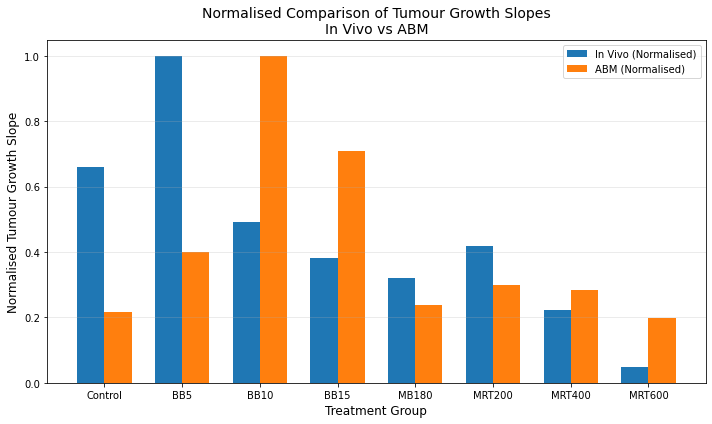


Treatment      In Vivo slope       ABM slope    IV norm   ABM norm
-----------------------------------------------------------------
Control               1.3214        0.000804      0.661      0.217
BB5                   2.0000        0.001482      1.000      0.399
BB10                  0.9826        0.003714      0.491      1.000
BB15                  0.7667        0.002631      0.383      0.708
MB180                 0.6392        0.000887      0.320      0.239
MRT200                0.8373        0.001114      0.419      0.300
MRT400                0.4460        0.001060      0.223      0.285
MRT600                0.0989        0.000735      0.049      0.198


In [13]:
from scipy.stats import linregress

# --- In vivo data (Romano et al.) — same as above ---
in_vivo_slopes_data = {
    "Control": [(12, 2), (20, 12), (24, 18)],
    "BB5":     [(12, 2), (21, 20)],
    "BB10":    [(12, 2), (28, 15), (38, 28)],
    "BB15":    [(12, 2), (42, 25)],
    "MB180":   [(12, 2), (25, 10), (29, 13)],
    "MRT200":  [(12, 2), (21, 2), (26, 14), (29, 15)],
    "MRT400":  [(12, 2), (49, 68), (57, 40), (62, 0)],
    "MRT600":  [(12, 2), (54, 18), (62, 0)],
}

# Compute in vivo slopes via linear regression
in_vivo_slopes = {}
for treatment, points in in_vivo_slopes_data.items():
    x, y = zip(*points)
    slope, _, _, _, _ = linregress(x, y)
    in_vivo_slopes[treatment] = slope

# --- ABM slopes from simulation data ---
# Use tumour volume (% brain) over Day 12–60 window (post-radiation)
slope_scenarios = ["Control", "BB5", "BB10", "BB15", "MB180", "MRT200", "MRT400", "MRT600"]

abm_slopes = {}
for scen in slope_scenarios:
    if scen in scenario_data:
        d = scenario_data[scen]
        # Fit slope over the post-radiation window
        mask = (d['days'] >= 12) & (d['days'] <= 60)
        x = d['days'][mask].astype(float)
        y = d['mean'][mask]
        slope, _, _, _, _ = linregress(x, y)
        abm_slopes[scen] = slope

# --- Normalise both to [0, 1] ---
iv_max = max(in_vivo_slopes.values())
abm_max = max(abm_slopes.values())

iv_norm  = {k: v / iv_max for k, v in in_vivo_slopes.items()}
abm_norm = {k: v / abm_max for k, v in abm_slopes.items()}

# --- Plot ---
treatments = list(in_vivo_slopes.keys())
x = np.arange(len(treatments))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_iv  = ax.bar(x - bar_width/2, [iv_norm[t] for t in treatments],
                  bar_width, label='In Vivo (Normalised)', color='#1f77b4')
bars_abm = ax.bar(x + bar_width/2, [abm_norm.get(t, 0) for t in treatments],
                  bar_width, label='ABM (Normalised)', color='#ff7f0e')

ax.set_xlabel('Treatment Group', fontsize=12)
ax.set_ylabel('Normalised Tumour Growth Slope', fontsize=12)
ax.set_title('Normalised Comparison of Tumour Growth Slopes\nIn Vivo vs ABM', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(treatments, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('HALModeling2024Outs/slope_comparison_invivo_vs_abm.png', dpi=200, bbox_inches='tight')
plt.show()

# Print slopes for reference
print(f"\n{'Treatment':<12} {'In Vivo slope':>15} {'ABM slope':>15} {'IV norm':>10} {'ABM norm':>10}")
print("-" * 65)
for t in treatments:
    print(f"{t:<12} {in_vivo_slopes[t]:>15.4f} {abm_slopes.get(t, 0):>15.6f} {iv_norm[t]:>10.3f} {abm_norm.get(t, 0):>10.3f}")

### Summary table: final tumour volume per scenario

In [14]:
# Summary table: volume at key timepoints and at end of simulation
print(f"{'Scenario':<12} {'Trials':>6} {'Vol at Day 42':>15} {'Vol at Day 72':>15} {'Final Vol':>15} {'Final Day':>10}")
print("-" * 75)

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    
    # Find index for specific days
    day42_idx = np.argmin(np.abs(d['days'] - 42))
    day72_idx = np.argmin(np.abs(d['days'] - 72))
    
    vol42 = f"{d['mean'][day42_idx]:.4f}%"
    vol72 = f"{d['mean'][day72_idx]:.4f}%"
    vol_final = f"{d['mean'][-1]:.4f}%"
    final_day = f"{d['days'][-1]}"
    
    print(f"{scen:<12} {d['n_trials']:>6} {vol42:>15} {vol72:>15} {vol_final:>15} {final_day:>10}")

Scenario     Trials   Vol at Day 42   Vol at Day 72       Final Vol  Final Day
---------------------------------------------------------------------------
Control          10         0.1957%         0.2164%         0.4245%        352
BB5              10         0.1281%         0.1954%         0.4222%        352
BB10             10         0.1245%         0.2109%         0.4265%        352
BB15             10         0.0673%         0.1677%         0.4205%        352
MRT200           10         0.0780%         0.1278%         0.4138%        352
MRT400           10         0.0562%         0.1058%         0.4161%        352
MRT600           10         0.0322%         0.0717%         0.4148%        352
MB180            10         0.0518%         0.0934%         0.4181%        352
MB350            10         0.0233%         0.0521%         0.4222%        352


### Relative growth: normalised to volume at treatment day

This shows how much the tumour grew or shrank *relative to the treatment day*, 
making it easier to compare treatment effectiveness across scenarios regardless 
of the absolute volume scale.

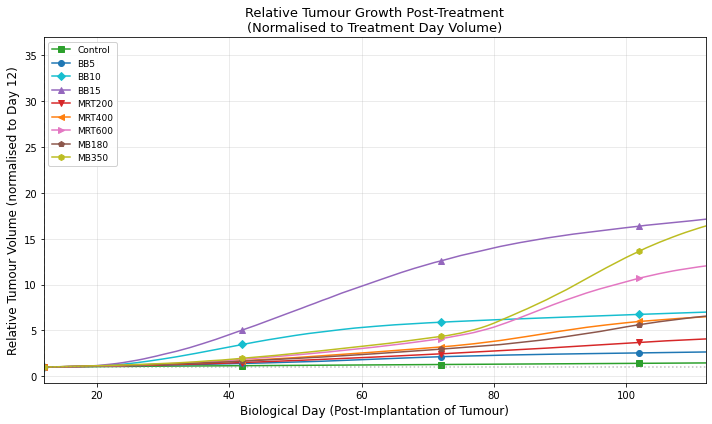

Saved to HALModeling2024Outs/tumour_volume_relative.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for scen in scenarios:
    if scen not in scenario_data:
        continue
    d = scenario_data[scen]
    style = scenario_style[scen]
    
    mask = d['days'] >= RADIATION_DAY
    days = d['days'][mask]
    mean = d['mean'][mask]
    
    # Normalise to volume at treatment day
    vol_at_treatment = mean[0] if mean[0] > 0 else 1e-9
    normalised = mean / vol_at_treatment
    
    ax.plot(days, normalised,
            color=style['color'],
            marker=style['marker'],
            markevery=30,
            markersize=6,
            linewidth=1.5,
            label=style['label'])

ax.axhline(y=1.0, color='grey', linestyle=':', alpha=0.5)
ax.axvline(x=RADIATION_DAY, color='grey', linestyle='--', alpha=0.5)

ax.set_xlabel('Biological Day (Post-Implantation of Tumour)', fontsize=12)
ax.set_ylabel('Relative Tumour Volume (normalised to Day 12)', fontsize=12)
ax.set_title('Relative Tumour Growth Post-Treatment\n(Normalised to Treatment Day Volume)', fontsize=13)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(RADIATION_DAY, 112)

plt.tight_layout()
plt.savefig('HALModeling2024Outs/tumour_volume_relative.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to HALModeling2024Outs/tumour_volume_relative.png")